# HumanLens AI — Aggression Baseline

## Objective

This notebook develops an interpretable baseline for estimating
aggressive communication within the HumanLens text layer.

Aggression is treated as a behavioral-language signal rather than a
medical or psychological diagnosis.

## Research Challenge

The available toxicity datasets do not provide a direct ground-truth
"aggression" label.

Therefore, this experiment does not claim to train a validated
aggression classifier.

Instead, an explainable aggression proxy is constructed using
available harmful-language signals:

- Toxicity
- Insult
- Threat

The resulting score is intended as an intermediate research feature
for the HumanLens Multimodal Fusion Engine.

## Design Principle

Threat-related language should contribute strongly to aggression,
while insult and general toxicity provide supporting evidence.

The aggression score will remain continuous so that it can later be
combined with voice, facial-expression and behavioral signals.

## Important Limitation

The aggression proxy is not equivalent to human-annotated aggression.

It should therefore be validated against suitable aggression-labelled
data in future research.

The score must not be interpreted as evidence that a person is
intrinsically aggressive or dangerous.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
data_path = Path(
    "../data/processed/civil_comments_train_dev_100k.csv"
)

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("=" * 50)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully.
Shape: (100000, 9)

Columns:
['text', 'toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack', 'sexual_explicit', 'is_toxic']


In [3]:
aggression_features = [
    "toxicity",
    "threat",
    "insult"
]

print("Aggression-related features")
print("=" * 50)

for feature in aggression_features:
    print(f"\n{feature.upper()}")
    print(df[feature].describe())

Aggression-related features

TOXICITY
count    100000.000000
mean          0.102230
std           0.195581
min           0.000000
25%           0.000000
50%           0.000000
75%           0.166667
max           1.000000
Name: toxicity, dtype: float64

THREAT
count    100000.000000
mean          0.009248
std           0.048584
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: threat, dtype: float64

INSULT
count    100000.000000
mean          0.080367
std           0.174400
min           0.000000
25%           0.000000
50%           0.000000
75%           0.045455
max           1.000000
Name: insult, dtype: float64


In [4]:
print("Missing values in aggression features")
print("=" * 50)

print(
    df[aggression_features]
    .isnull()
    .sum()
)

Missing values in aggression features
toxicity    0
threat      0
insult      0
dtype: int64


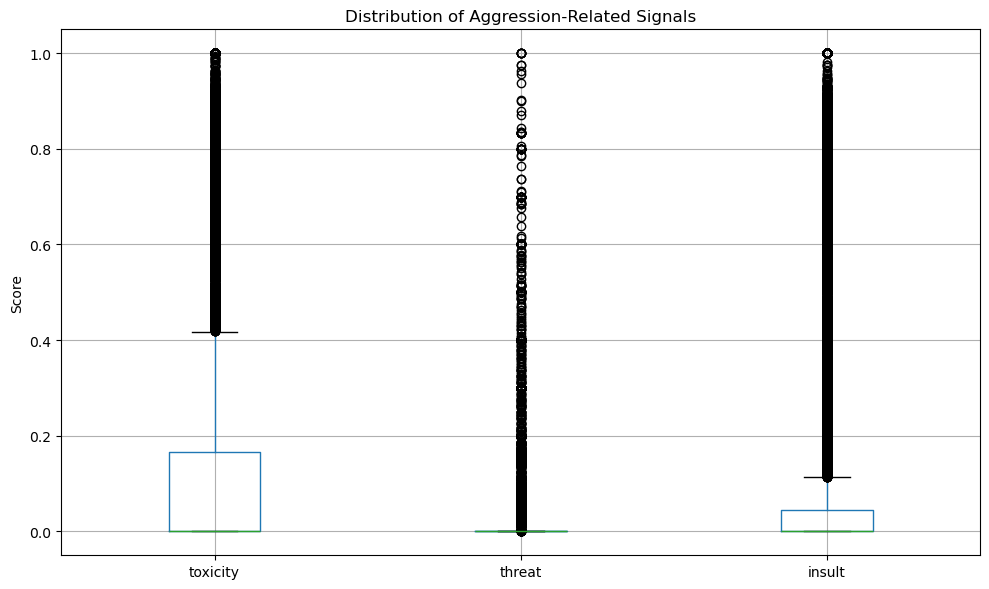

In [5]:
plt.figure(figsize=(10, 6))

df[aggression_features].boxplot()

plt.title("Distribution of Aggression-Related Signals")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

In [6]:
correlation_matrix = df[aggression_features].corr()

print(correlation_matrix)

          toxicity    threat    insult
toxicity  1.000000  0.291480  0.928956
threat    0.291480  1.000000  0.115846
insult    0.928956  0.115846  1.000000


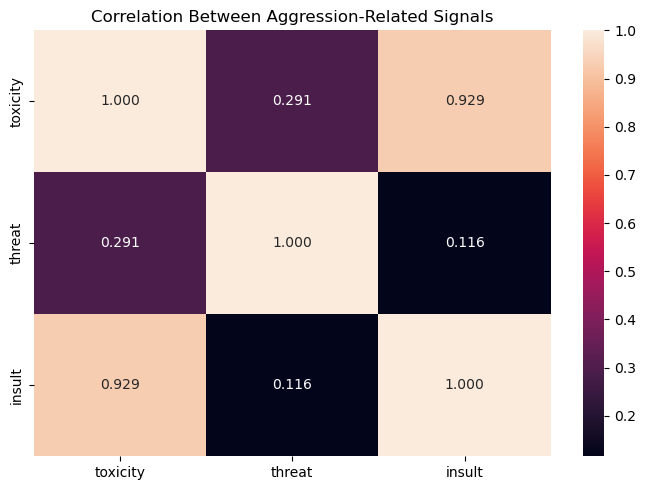

In [7]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f"
)

plt.title("Correlation Between Aggression-Related Signals")

plt.tight_layout()
plt.show()

In [8]:
THREAT_WEIGHT = 0.45
INSULT_WEIGHT = 0.35
TOXICITY_WEIGHT = 0.20

df["aggression_score"] = (
    THREAT_WEIGHT * df["threat"]
    + INSULT_WEIGHT * df["insult"]
    + TOXICITY_WEIGHT * df["toxicity"]
)

print("Aggression proxy created.")
print(df["aggression_score"].describe())

Aggression proxy created.
count    100000.000000
mean          0.052736
std           0.104775
min           0.000000
25%           0.000000
50%           0.000000
75%           0.075000
max           0.910000
Name: aggression_score, dtype: float64


In [9]:
print("Minimum aggression score:",
      df["aggression_score"].min())

print("Maximum aggression score:",
      df["aggression_score"].max())

print("Weights sum:",
      THREAT_WEIGHT +
      INSULT_WEIGHT +
      TOXICITY_WEIGHT)

Minimum aggression score: 0.0
Maximum aggression score: 0.9099999999999999
Weights sum: 1.0


In [10]:
def aggression_category(score):

    if score < 0.25:
        return "Low"

    elif score < 0.50:
        return "Moderate"

    elif score < 0.75:
        return "High"

    else:
        return "Very High"


df["aggression_category"] = (
    df["aggression_score"]
    .apply(aggression_category)
)

print(
    df["aggression_category"]
    .value_counts()
)

aggression_category
Low          92760
Moderate      6776
High           454
Very High       10
Name: count, dtype: int64


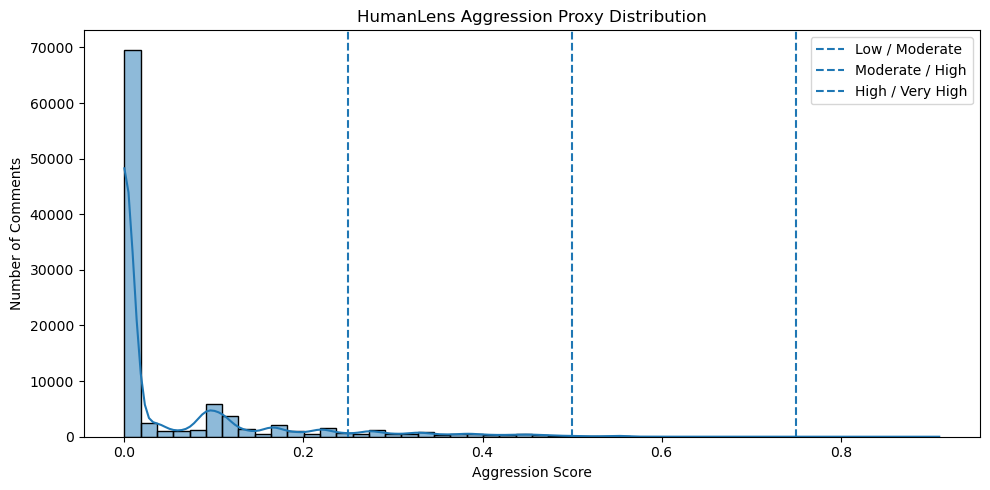

In [11]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["aggression_score"],
    bins=50,
    kde=True
)

plt.axvline(
    0.25,
    linestyle="--",
    label="Low / Moderate"
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Moderate / High"
)

plt.axvline(
    0.75,
    linestyle="--",
    label="High / Very High"
)

plt.title("HumanLens Aggression Proxy Distribution")
plt.xlabel("Aggression Score")
plt.ylabel("Number of Comments")
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
category_counts = (
    df["aggression_category"]
    .value_counts()
    .reindex(
        ["Low", "Moderate", "High", "Very High"]
    )
)

print(category_counts)

aggression_category
Low          92760
Moderate      6776
High           454
Very High       10
Name: count, dtype: int64


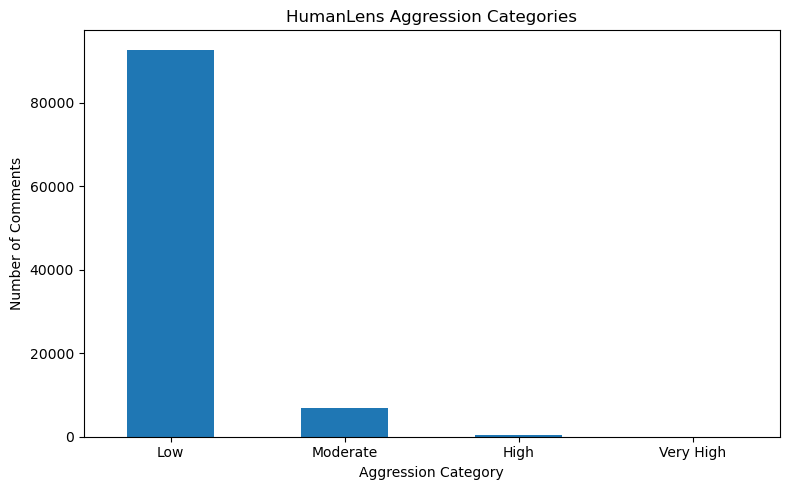

In [13]:
plt.figure(figsize=(8, 5))

category_counts.plot(kind="bar")

plt.title("HumanLens Aggression Categories")
plt.xlabel("Aggression Category")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [14]:
comparison = df[
    ["toxicity", "aggression_score"]
].describe()

comparison

,toxicity,aggression_score
count,100000.000000,100000.000000
mean,0.102230,0.052736
std,0.195581,0.104775
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.166667,0.075000
max,1.000000,0.910000


In [15]:
toxicity_aggression_corr = df[
    ["toxicity", "aggression_score"]
].corr()

toxicity_aggression_corr

,toxicity,aggression_score
toxicity,1.000000,0.975353
aggression_score,0.975353,1.000000


In [16]:
high_aggression = (
    df.sort_values(
        "aggression_score",
        ascending=False
    )
    [
        [
            "text",
            "toxicity",
            "insult",
            "threat",
            "aggression_score",
            "aggression_category"
        ]
    ]
    .head(20)
)

display(high_aggression)

,text,toxicity,insult,threat,aggression_score,aggression_category
22905,It's time to go full on Jedi Knight against th...,1.000000,1.000000,0.800000,0.910000,Very High
34215,Sick bastards should be shot.,0.942857,0.900000,0.842857,0.882857,Very High
71372,"DRUG DEALERS ARE MURDERS AND TERRORIST, kill t...",0.987847,0.645833,0.975694,0.862674,Very High
36611,Hope your pigs are ready to burn where they be...,0.935180,0.855402,0.804986,0.848670,Very High
57741,we'll beat your ass and cut your throat maggot.,0.992177,0.548892,0.962190,0.823533,Very High
53382,Bankrupt these fools. Hope the victim's family...,1.000000,1.000000,0.600000,0.820000,Very High
86565,SCUM. Like trump and his family. Die.,0.928571,0.900000,0.685714,0.809286,Very High
67933,"Yes, what he was saying is, we should be all i...",0.951613,0.951613,0.612903,0.799194,Very High
54518,Human trash. Flush him.,0.891892,0.851351,0.675676,0.780405,Very High
13116,Quarantine should end with a bullet between th...,1.000000,0.600000,0.800000,0.770000,Very High


In [17]:
high_toxicity_lower_aggression = df[
    (df["toxicity"] >= 0.75) &
    (df["aggression_score"] < 0.50)
][
    [
        "text",
        "toxicity",
        "insult",
        "threat",
        "aggression_score"
    ]
].sort_values(
    "toxicity",
    ascending=False
)

display(
    high_toxicity_lower_aggression.head(20)
)

,text,toxicity,insult,threat,aggression_score
33528,OK............. then require to show the damn ...,1.0,0.500000,0.000000,0.375000
31727,Damn. That's about the fourth cop I've encoun...,1.0,0.300000,0.000000,0.305000
56026,"Yep Randy, statistics and facts, but those don...",1.0,0.800000,0.000000,0.480000
2590,It's unsurprising that you immediately mention...,1.0,0.500000,0.000000,0.375000
27079,There is truth in what you say -- nations in t...,1.0,0.000000,0.000000,0.200000
76676,Yup. Nothing like a NIMBY hypocrite. Like the ...,1.0,0.833333,0.000000,0.491667
51403,What an extremely stupid decision by that judg...,1.0,0.700000,0.000000,0.445000
3360,And that's why his campaign defended his state...,1.0,0.833333,0.000000,0.491667
78293,Cause the dummies no vote,1.0,0.833333,0.000000,0.491667
27609,"Darn, what a loss",1.0,0.400000,0.000000,0.340000


In [18]:
high_aggression_lower_toxicity = df[
    (df["aggression_score"] >= 0.75) &
    (df["toxicity"] < 0.50)
][
    [
        "text",
        "toxicity",
        "insult",
        "threat",
        "aggression_score"
    ]
].sort_values(
    "aggression_score",
    ascending=False
)

display(
    high_aggression_lower_toxicity.head(20)
)

,text,toxicity,insult,threat,aggression_score


In [19]:
print("Language information available:")

if "language" in df.columns:
    print(df["language"].value_counts())
else:
    print("Civil Comments development dataset is treated as English.")

Language information available:
Civil Comments development dataset is treated as English.


In [20]:
humanlens_text_signals = df[
    [
        "text",
        "toxicity",
        "insult",
        "threat",
        "aggression_score",
        "aggression_category"
    ]
].copy()

humanlens_text_signals.head(20)

,text,toxicity,insult,threat,aggression_score,aggression_category
0,Socialists? What the hell does that have to do...,0.300000,0.200000,0.000000,0.130000,Low
1,And I always thought that Eric Trump was the d...,0.808824,0.794118,0.000000,0.439706,Moderate
2,I’m disappointed there’s no report from CB on ...,0.000000,0.000000,0.000000,0.000000,Low
3,Nothing like subsidizing a country that is thr...,0.166667,0.166667,0.000000,0.091667,Low
4,The only way to save the rhino is to legalize ...,0.000000,0.000000,0.000000,0.000000,Low
5,"Careful, your misogyny is showing.",0.500000,0.500000,0.000000,0.275000,Moderate
6,If they paid more than $14 an hour to do the w...,0.000000,0.000000,0.000000,0.000000,Low
7,Lynn I read the comments and most were very qu...,0.000000,0.000000,0.000000,0.000000,Low
8,gary - All of my firearms are registered. Why...,0.000000,0.000000,0.000000,0.000000,Low
9,Love it!,0.000000,0.000000,0.000000,0.000000,Low


In [21]:
results_dir = Path("../results")
results_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    results_dir /
    "aggression_baseline_results.csv"
)

humanlens_text_signals.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("Aggression results saved successfully.")
print(output_path)

Aggression results saved successfully.
..\results\aggression_baseline_results.csv


In [22]:
parameters = pd.DataFrame({
    "parameter": [
        "threat_weight",
        "insult_weight",
        "toxicity_weight",
        "low_threshold",
        "moderate_threshold",
        "high_threshold"
    ],
    "value": [
        THREAT_WEIGHT,
        INSULT_WEIGHT,
        TOXICITY_WEIGHT,
        0.25,
        0.50,
        0.75
    ]
})

parameters_path = (
    results_dir /
    "aggression_baseline_parameters.csv"
)

parameters.to_csv(
    parameters_path,
    index=False
)

print("Parameters saved successfully.")

Parameters saved successfully.


# Aggression Baseline — Research Findings

## Approach

A deterministic aggression proxy was developed because the primary
datasets do not provide a direct human-annotated aggression label.

The proxy combines:

- Threat
- Insult
- Toxicity

using an initial weighted scoring scheme.

## Aggression Score

The initial score is calculated as:

Aggression Score =
0.45 × Threat +
0.35 × Insult +
0.20 × Toxicity

The score is normalized to the range [0, 1].

## Interpretation

The aggression score represents the strength of aggressive-language
signals detected in the text.

It does not represent a psychological assessment of the user.

## Research Limitation

Because this is a proxy rather than a human-annotated aggression
target, the resulting score should not be described as validated
aggression classification.

Future work should evaluate the approach against an independently
annotated aggression dataset.

## HumanLens Integration

The aggression score is designed as an independent text-layer signal.

It will later be combined with:

- Toxicity
- Emotion
- Voice features
- Facial-expression features
- Behavioral trends

within the HumanLens Multimodal Fusion Engine.

## Next Research Stage

The next stage is emotion analysis, followed by behavioral,
voice, facial and multimodal feature experiments.